# Projekt 4 - Treasure Escape RL

Ten notatnik zawiera rozwiązanie projektu: własne środowisko Gymnasium, trening agenta RL metodą Q-learning, zapis krzywej uczenia oraz uruchomienie wytrenowanego agenta w grze.

Gra: agent startuje w labiryncie, musi zebrać skarb `T`, a potem dojść do wyjścia `E`. Ściany `#` blokują ruch, a pułapki `X` kończą epizod porażką.

## 1. Instalacja ii importy

In [2]:
# %pip install -q gymnasium pygame numpy matplotlib pandas

import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")


from collections import deque
from dataclasses import dataclass
from enum import IntEnum
from pathlib import Path
from typing import Any
import csv
import time

import gymnasium as gym
from gymnasium import spaces
from gymnasium.error import DependencyNotInstalled
import matplotlib.pyplot as plt
import numpy as np

try:
    import pygame
except ImportError:
    pygame = None

<frozen importlib._bootstrap>:491: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.


## 2. Definicja środowiska Gymnasium

Środowisko generuje zestaw różnych losowych, ale rozwiązywalnych map. Różnią się pozycją startu, skarbu, wyjścia, ścian i pułapek. Przy każdym `reset()` wybierana jest jedna z map, więc trening nie odbywa się ciągle na identycznej planszy.

In [3]:

class Actions(IntEnum):
    RIGHT = 0
    UP = 1
    LEFT = 2
    DOWN = 3


MAP_SIZE = 10
NUM_TRAINING_MAPS = 12
MAP_GENERATION_SEED = 2026


def shortest_path_length_on_grid(walls, traps, start, goal):
    queue = deque([(start, 0)])
    visited = {start}
    directions = [(0, 1), (-1, 0), (0, -1), (1, 0)]

    while queue:
        current, distance = queue.popleft()
        if current == goal:
            return distance
        for dr, dc in directions:
            nxt = (current[0] + dr, current[1] + dc)
            if (
                nxt in visited
                or not (0 <= nxt[0] < walls.shape[0] and 0 <= nxt[1] < walls.shape[1])
                or walls[nxt] == 1
                or traps[nxt] == 1
            ):
                continue
            visited.add(nxt)
            queue.append((nxt, distance + 1))
    return None


def generate_random_map(rng, size=MAP_SIZE, wall_probability=0.16, trap_probability=0.04):
    interior = [(row, col) for row in range(1, size - 1) for col in range(1, size - 1)]

    for _ in range(10_000):
        walls = np.zeros((size, size), dtype=np.int8)
        traps = np.zeros((size, size), dtype=np.int8)
        walls[0, :] = 1
        walls[-1, :] = 1
        walls[:, 0] = 1
        walls[:, -1] = 1

        shuffled = interior.copy()
        rng.shuffle(shuffled)
        start, treasure, exit_location = shuffled[:3]
        special = {start, treasure, exit_location}

        for position in interior:
            if position in special:
                continue
            roll = rng.random()
            if roll < wall_probability:
                walls[position] = 1
            elif roll < wall_probability + trap_probability:
                traps[position] = 1

        dist_to_treasure = shortest_path_length_on_grid(walls, traps, start, treasure)
        dist_to_exit = shortest_path_length_on_grid(walls, traps, treasure, exit_location)
        if dist_to_treasure is None or dist_to_exit is None:
            continue
        if dist_to_treasure < 5 or dist_to_exit < 5:
            continue

        rows = []
        for row in range(size):
            chars = []
            for col in range(size):
                pos = (row, col)
                if pos == start:
                    chars.append("S")
                elif pos == treasure:
                    chars.append("T")
                elif pos == exit_location:
                    chars.append("E")
                elif walls[pos]:
                    chars.append("#")
                elif traps[pos]:
                    chars.append("X")
                else:
                    chars.append(".")
            rows.append("".join(chars))
        return tuple(rows)

    raise RuntimeError("Nie udalo sie wygenerowac rozwiązywalnej mapy.")


def generate_training_maps(count=NUM_TRAINING_MAPS, seed=MAP_GENERATION_SEED):
    rng = np.random.default_rng(seed)
    maps = []
    signatures = set()
    while len(maps) < count:
        generated_map = generate_random_map(rng)
        signature = "\n".join(generated_map)
        if signature in signatures:
            continue
        signatures.add(signature)
        maps.append(generated_map)
    return tuple(maps)


DEFAULT_MAPS = generate_training_maps()


class TreasureEscapeEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 8}

    def __init__(self, render_mode=None, map_id=None, maps=DEFAULT_MAPS, max_steps=140, window_size=600):
        assert render_mode is None or render_mode in self.metadata["render_modes"]
        self.render_mode = render_mode
        self.map_id = map_id
        self.maps = tuple(maps)
        self.max_steps = max_steps
        self.window_size = window_size
        self.size = len(self.maps[0])

        self.observation_space = spaces.Dict(
            {
                "map_id": spaces.Discrete(len(self.maps)),
                "agent": spaces.Box(0, self.size - 1, shape=(2,), dtype=np.int64),
                "treasure": spaces.Box(0, self.size - 1, shape=(2,), dtype=np.int64),
                "exit": spaces.Box(0, self.size - 1, shape=(2,), dtype=np.int64),
                "has_treasure": spaces.Discrete(2),
                "walls": spaces.MultiBinary((self.size, self.size)),
                "traps": spaces.MultiBinary((self.size, self.size)),
            }
        )
        self.action_space = spaces.Discrete(len(Actions))
        self._action_to_direction = {
            Actions.RIGHT.value: np.array([0, 1], dtype=np.int64),
            Actions.UP.value: np.array([-1, 0], dtype=np.int64),
            Actions.LEFT.value: np.array([0, -1], dtype=np.int64),
            Actions.DOWN.value: np.array([1, 0], dtype=np.int64),
        }

        self.window = None
        self.clock = None
        self._walls = np.zeros((self.size, self.size), dtype=np.int8)
        self._traps = np.zeros((self.size, self.size), dtype=np.int8)
        self._agent_location = np.zeros(2, dtype=np.int64)
        self._start_location = np.zeros(2, dtype=np.int64)
        self._treasure_location = np.zeros(2, dtype=np.int64)
        self._exit_location = np.zeros(2, dtype=np.int64)
        self._has_treasure = 0
        self._step_count = 0
        self._current_map_id = 0

    def _parse_map(self, map_lines):
        self._walls.fill(0)
        self._traps.fill(0)
        start = treasure = exit_location = None

        for row, line in enumerate(map_lines):
            for col, tile in enumerate(line):
                position = np.array([row, col], dtype=np.int64)
                if tile == "#":
                    self._walls[row, col] = 1
                elif tile == "X":
                    self._traps[row, col] = 1
                elif tile == "S":
                    start = position
                elif tile == "T":
                    treasure = position
                elif tile == "E":
                    exit_location = position

        if start is None or treasure is None or exit_location is None:
            raise ValueError("Mapa musi zawierac S, T i E.")

        self._start_location = start
        self._agent_location = start.copy()
        self._treasure_location = treasure
        self._exit_location = exit_location

    def _get_obs(self):
        return {
            "map_id": int(self._current_map_id),
            "agent": self._agent_location.copy(),
            "treasure": self._treasure_location.copy(),
            "exit": self._exit_location.copy(),
            "has_treasure": int(self._has_treasure),
            "walls": self._walls.copy(),
            "traps": self._traps.copy(),
        }

    def _shortest_path_length(self, start, goal):
        return shortest_path_length_on_grid(
            self._walls,
            self._traps,
            tuple(int(v) for v in start),
            tuple(int(v) for v in goal),
        )

    def _get_info(self):
        target = self._exit_location if self._has_treasure else self._treasure_location
        return {
            "map_id": int(self._current_map_id),
            "steps": self._step_count,
            "has_treasure": bool(self._has_treasure),
            "distance_to_current_target": self._shortest_path_length(self._agent_location, target),
            "success": bool(self._has_treasure and np.array_equal(self._agent_location, self._exit_location)),
        }

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        requested_map_id = self.map_id
        if options and "map_id" in options:
            requested_map_id = int(options["map_id"])
        if requested_map_id is None:
            requested_map_id = int(self.np_random.integers(len(self.maps)))

        self._current_map_id = requested_map_id % len(self.maps)
        self._parse_map(self.maps[self._current_map_id])
        self._has_treasure = 0
        self._step_count = 0

        if self.render_mode == "human":
            self._render_frame()
        return self._get_obs(), self._get_info()

    def step(self, action):
        action = int(action)
        self._step_count += 1
        reward = -0.01
        terminated = False
        truncated = False
        event = "move"

        direction = self._action_to_direction[action]
        new_location = self._agent_location + direction
        row, col = int(new_location[0]), int(new_location[1])
        blocked = (
            row < 0 or row >= self.size or col < 0 or col >= self.size or self._walls[row, col] == 1
        )

        if blocked:
            reward -= 0.2
            event = "blocked"
        else:
            self._agent_location = new_location
            if self._traps[row, col] == 1:
                reward -= 2.0
                terminated = True
                event = "trap"
            elif not self._has_treasure and np.array_equal(self._agent_location, self._treasure_location):
                self._has_treasure = 1
                reward += 1.0
                event = "treasure"
            elif np.array_equal(self._agent_location, self._exit_location):
                if self._has_treasure:
                    reward += 5.0
                    terminated = True
                    event = "escaped"
                else:
                    reward -= 0.5
                    event = "locked_exit"

        if self._step_count >= self.max_steps and not terminated:
            truncated = True
            reward -= 1.0
            event = "timeout"

        info = self._get_info()
        info["event"] = event
        if self.render_mode == "human":
            self._render_frame()
        return self._get_obs(), float(reward), terminated, truncated, info

    def render(self):
        if self.render_mode in ("human", "rgb_array"):
            return self._render_frame()
        return None

    def _render_frame(self):
        if pygame is None:
            raise DependencyNotInstalled("pygame jest wymagany do renderowania.")

        if self.window is None and self.render_mode == "human":
            pygame.init()
            pygame.display.init()
            self.window = pygame.display.set_mode((self.window_size, self.window_size))
            pygame.display.set_caption("Treasure Escape")
        if self.clock is None and self.render_mode == "human":
            self.clock = pygame.time.Clock()

        canvas = pygame.Surface((self.window_size, self.window_size))
        canvas.fill((245, 246, 248))
        cell_size = self.window_size / self.size
        colors = {
            "floor": (245, 246, 248),
            "wall": (35, 40, 48),
            "trap": (190, 44, 44),
            "grid": (210, 214, 220),
            "treasure": (245, 184, 53),
            "exit_locked": (120, 130, 145),
            "exit_open": (41, 145, 88),
            "agent": (45, 102, 210),
        }

        for row in range(self.size):
            for col in range(self.size):
                rect = pygame.Rect(round(col * cell_size), round(row * cell_size), round(cell_size), round(cell_size))
                if self._walls[row, col]:
                    pygame.draw.rect(canvas, colors["wall"], rect)
                elif self._traps[row, col]:
                    pygame.draw.rect(canvas, colors["trap"], rect)
                else:
                    pygame.draw.rect(canvas, colors["floor"], rect)
                pygame.draw.rect(canvas, colors["grid"], rect, 1)

        if not self._has_treasure:
            treasure_center = (
                round((self._treasure_location[1] + 0.5) * cell_size),
                round((self._treasure_location[0] + 0.5) * cell_size),
            )
            pygame.draw.circle(canvas, colors["treasure"], treasure_center, round(cell_size * 0.28))

        exit_rect = pygame.Rect(
            round((self._exit_location[1] + 0.18) * cell_size),
            round((self._exit_location[0] + 0.18) * cell_size),
            round(cell_size * 0.64),
            round(cell_size * 0.64),
        )
        pygame.draw.rect(canvas, colors["exit_open"] if self._has_treasure else colors["exit_locked"], exit_rect, border_radius=6)

        agent_center = (
            round((self._agent_location[1] + 0.5) * cell_size),
            round((self._agent_location[0] + 0.5) * cell_size),
        )
        pygame.draw.circle(canvas, colors["agent"], agent_center, round(cell_size * 0.3))

        if self.render_mode == "human":
            self.window.blit(canvas, canvas.get_rect())
            pygame.event.pump()
            pygame.display.update()
            self.clock.tick(self.metadata["render_fps"])
            return None

        return np.transpose(np.array(pygame.surfarray.pixels3d(canvas)), axes=(1, 0, 2))

    def close(self):
        if self.window is not None and pygame is not None:
            pygame.display.quit()
            pygame.quit()
        self.window = None
        self.clock = None


print(f"Wygenerowano {len(DEFAULT_MAPS)} roznych map treningowych.")
for map_id, generated_map in enumerate(DEFAULT_MAPS[:3]):
    print(f"\nMapa {map_id}:")
    print("\n".join(generated_map))


Wygenerowano 12 roznych map treningowych.

Mapa 0:
##########
##.#....T#
#..#..X..#
#S....#.##
##......##
#.X.E....#
#....#..X#
#......X.#
#.......##
##########

Mapa 1:
##########
#...S....#
#.......##
#E..#....#
#.##...X##
#........#
#.....##.#
#...#.X..#
#..#XT...#
##########

Mapa 2:
##########
#...XE...#
#..#...#.#
#..#....##
#..#.....#
##.......#
#......###
#...S#...#
#...#..#T#
##########


## 3. Agent Q-learning

Stan agenta RL to `(map_id, agent_row, agent_col, has_treasure)`. `map_id` jest potrzebny, bo uczymy jedną tablicę Q dla wielu różnych map. Agent wybiera akcje strategią epsilon-greedy: na początku dużo eksploruje, a później coraz częściej używa najlepszej znanej akcji.

In [4]:
@dataclass
class TrainingConfig:
    episodes: int = 1000
    alpha: float = 0.18
    gamma: float = 0.97
    epsilon_start: float = 1.0
    epsilon_end: float = 0.03
    epsilon_decay: float = 0.996
    shaping_scale: float = 0.03
    seed: int = 11


class QLearningAgent:
    def __init__(self, q_table, epsilon, rng):
        self.q_table = q_table
        self.epsilon = epsilon
        self.rng = rng

    @classmethod
    def fresh(cls, env, epsilon, rng):
        q_shape = (len(DEFAULT_MAPS), env.size, env.size, 2, env.action_space.n)
        return cls(np.zeros(q_shape, dtype=np.float64), epsilon, rng)

    @classmethod
    def load(cls, path, epsilon=0.0, seed=0):
        return cls(np.load(path), epsilon, np.random.default_rng(seed))

    def state_index(self, observation):
        row, col = (int(v) for v in observation["agent"])
        return (int(observation["map_id"]), row, col, int(observation["has_treasure"]))

    def choose_action(self, observation, explore=True):
        state = self.state_index(observation)
        if explore and self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.q_table.shape[-1]))
        return int(np.argmax(self.q_table[state]))

    def update(self, observation, action, reward, next_observation, done, alpha, gamma):
        state = self.state_index(observation)
        next_state = self.state_index(next_observation)
        current_q = self.q_table[state + (action,)]
        next_best_q = 0.0 if done else float(np.max(self.q_table[next_state]))
        target_q = reward + gamma * next_best_q
        self.q_table[state + (action,)] = current_q + alpha * (target_q - current_q)


def shaped_reward(reward, previous_info, next_info, shaping_scale):
    previous_distance = previous_info["distance_to_current_target"]
    next_distance = next_info["distance_to_current_target"]
    if previous_distance is None or next_distance is None:
        return reward
    return reward + shaping_scale * (previous_distance - next_distance)

## 4. Funkcje treningu, ewaluacji i zapisu krzywej uczenia

Po treningu zapisujemy trzy pliki: `q_table.npy`, `learning_curve.csv` oraz `learning_curve.png`.

In [5]:
def moving_average(values, window):
    if len(values) < window:
        return values
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def save_outputs(agent, history, output_dir):
    output_dir.mkdir(parents=True, exist_ok=True)
    np.save(output_dir / "q_table.npy", agent.q_table)

    with (output_dir / "learning_curve.csv").open("w", newline="", encoding="utf-8") as csvfile:
        writer = csv.DictWriter(csvfile, fieldnames=list(history[0].keys()))
        writer.writeheader()
        writer.writerows(history)

    episodes = np.array([row["episode"] for row in history], dtype=np.int64)
    rewards = np.array([row["reward"] for row in history], dtype=np.float64)
    success = np.array([row["success"] for row in history], dtype=np.float64)
    window = min(100, max(1, len(history) // 10))
    reward_ma = moving_average(rewards, window)
    success_ma = moving_average(success, window)
    ma_episodes = episodes[window - 1:]

    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    axes[0].plot(episodes, rewards, color="0.78", linewidth=0.7, label="reward")
    axes[0].plot(ma_episodes, reward_ma, color="#1f77b4", linewidth=2, label=f"{window}-episode average")
    axes[0].set_ylabel("Episode reward")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(ma_episodes, success_ma, color="#2ca02c", linewidth=2)
    axes[1].set_xlabel("Episode")
    axes[1].set_ylabel("Success rate")
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].grid(alpha=0.25)

    fig.suptitle("Treasure Escape Q-learning curve")
    fig.tight_layout()
    fig.savefig(output_dir / "learning_curve.png", dpi=150)
    plt.show()


def train(config, output_dir):
    rng = np.random.default_rng(config.seed)
    env = TreasureEscapeEnv()
    agent = QLearningAgent.fresh(env, epsilon=config.epsilon_start, rng=rng)
    history = []

    for episode in range(1, config.episodes + 1):
        observation, info = env.reset(seed=config.seed + episode)
        total_env_reward = 0.0
        total_training_reward = 0.0
        terminated = truncated = False

        while not (terminated or truncated):
            action = agent.choose_action(observation, explore=True)
            next_observation, reward, terminated, truncated, next_info = env.step(action)
            done = terminated or truncated
            train_reward = shaped_reward(reward, info, next_info, config.shaping_scale)
            agent.update(observation, action, train_reward, next_observation, done, config.alpha, config.gamma)

            observation = next_observation
            info = next_info
            total_env_reward += reward
            total_training_reward += train_reward

        history.append(
            {
                "episode": episode,
                "reward": total_env_reward,
                "training_reward": total_training_reward,
                "steps": int(info["steps"]),
                "success": int(info["success"]),
                "epsilon": agent.epsilon,
            }
        )
        agent.epsilon = max(config.epsilon_end, agent.epsilon * config.epsilon_decay)

    env.close()
    save_outputs(agent, history, output_dir)
    return agent, history


def evaluate(agent, episodes=100, seed=12345, map_id=None, render=False, sleep=0.04):
    env = TreasureEscapeEnv(render_mode="human" if render else None, map_id=map_id)
    rewards, steps, successes = [], [], []

    for episode in range(episodes):
        observation, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        terminated = truncated = False

        while not (terminated or truncated):
            action = agent.choose_action(observation, explore=False)
            observation, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            if render:
                env.render()
                time.sleep(sleep)

        rewards.append(total_reward)
        steps.append(int(info["steps"]))
        successes.append(int(info["success"]))

    env.close()
    return {
        "episodes": episodes,
        "success_rate": float(np.mean(successes)),
        "avg_reward": float(np.mean(rewards)),
        "avg_steps": float(np.mean(steps)),
    }

## 5. Trening agenta RL

Komórka poniżej trenuje agenta na wielu różnych mapach. Dla szybkiego pokazu ustawiono `3000` epizodów, co daje agentowi wystarczająco dużo prób na każdej mapie z wygenerowanego zestawu.

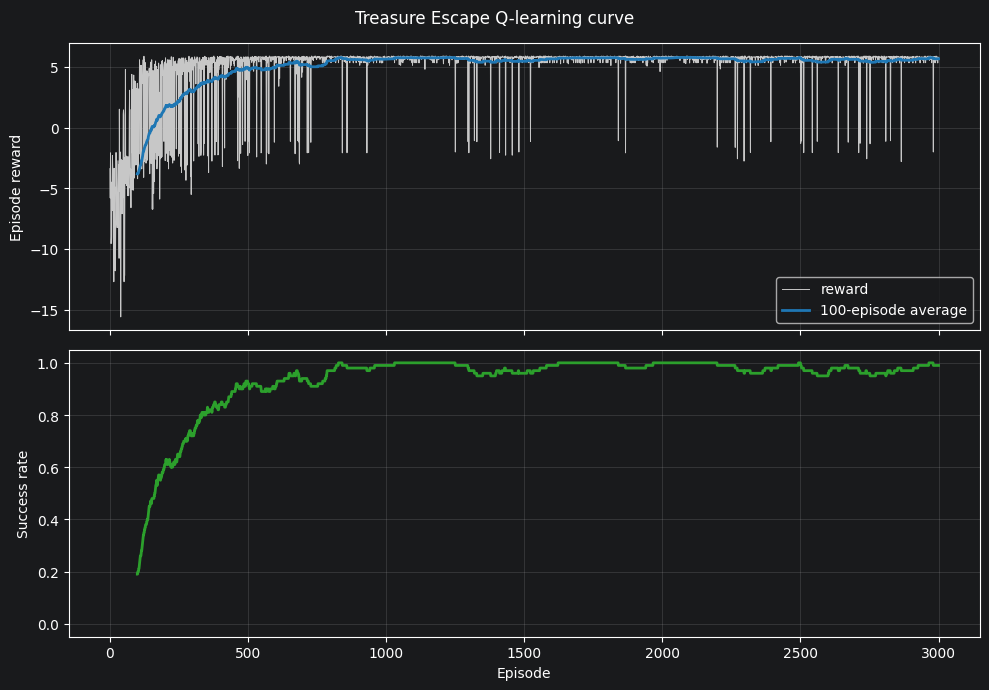

Zapisano Q-table: outputs/q_learning_notebook/q_table.npy
Zapisano dane krzywej: outputs/q_learning_notebook/learning_curve.csv
Zapisano wykres: outputs/q_learning_notebook/learning_curve.png
Pierwsze 5 epizodow: [{'episode': 1, 'reward': -3.38, 'training_reward': -3.26, 'steps': 18, 'success': 0, 'epsilon': 1.0}, {'episode': 2, 'reward': -5.799999999999982, 'training_reward': -5.830000000000001, 'steps': 140, 'success': 0, 'epsilon': 0.996}, {'episode': 3, 'reward': -2.0799999999999996, 'training_reward': -2.0199999999999996, 'steps': 8, 'success': 0, 'epsilon': 0.992016}, {'episode': 4, 'reward': -5.079999999999998, 'training_reward': -4.93, 'steps': 38, 'success': 0, 'epsilon': 0.988047936}, {'episode': 5, 'reward': -9.55999999999999, 'training_reward': -9.65, 'steps': 86, 'success': 0, 'epsilon': 0.984095744256}]
Ostatnie 5 epizodow: [{'episode': 2996, 'reward': 5.76, 'training_reward': 6.15, 'steps': 24, 'success': 1, 'epsilon': 0.03}, {'episode': 2997, 'reward': 5.33, 'training_r

In [6]:
OUTPUT_DIR = Path("outputs/q_learning_notebook")
config = TrainingConfig(episodes=3000, seed=11)
agent, history = train(config, OUTPUT_DIR)

print(f"Zapisano Q-table: {OUTPUT_DIR / 'q_table.npy'}")
print(f"Zapisano dane krzywej: {OUTPUT_DIR / 'learning_curve.csv'}")
print(f"Zapisano wykres: {OUTPUT_DIR / 'learning_curve.png'}")
print("Pierwsze 5 epizodow:", history[:5])
print("Ostatnie 5 epizodow:", history[-5:])

## 6. Ewaluacja po treningu

Po treningu wyłączamy eksplorację (`epsilon = 0`) i sprawdzamy, czy agent potrafi ukończyć grę.

In [7]:
trained_agent = QLearningAgent.load(OUTPUT_DIR / "q_table.npy", epsilon=0.0, seed=123)
metrics = evaluate(trained_agent, episodes=60, seed=100_000)
print("Ewaluacja wytrenowanego agenta bez eksploracji:")
print(f"  epizody:       {metrics['episodes']}")
print(f"  skutecznosc:   {metrics['success_rate']:.1%}")
print(f"  srednia nagroda: {metrics['avg_reward']:.3f}")
print(f"  srednie kroki: {metrics['avg_steps']:.1f}")
metrics


Ewaluacja wytrenowanego agenta bez eksploracji:
  epizody:       60
  skutecznosc:   100.0%
  srednia nagroda: 5.826
  srednie kroki: 16.6


{'episodes': 60,
 'success_rate': 1.0,
 'avg_reward': 5.826166666666666,
 'avg_steps': 16.55}

## 7. Uruchomienie kilku gier w notatniku

Poniższa komórka uruchamia kilka epizodów wytrenowanego agenta na różnych mapach i wyświetla animacje całej gry jako kolejne klatki `rgb_array`. Każdy epizod może mieć inne położenie startu, skarbu, wyjścia, ścian i pułapek, bo wybieramy inne `map_id`.

In [8]:
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation


def play_one_episode_as_frames(agent, seed=2026, map_id=None):
    env = TreasureEscapeEnv(render_mode="rgb_array", map_id=map_id)
    observation, info = env.reset(seed=seed)
    selected_map_id = info["map_id"]
    frames = [env.render()]
    total_reward = 0.0
    terminated = truncated = False

    while not (terminated or truncated):
        action = agent.choose_action(observation, explore=False)
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        frames.append(env.render())

    env.close()
    return frames, total_reward, info, selected_map_id


def show_episode_animation(frames, title, interval=180):
    fig, ax = plt.subplots(figsize=(6, 6))
    image = ax.imshow(frames[0])
    ax.axis("off")

    def update(frame_idx):
        image.set_data(frames[frame_idx])
        ax.set_title(f"{title} - klatka {frame_idx + 1}/{len(frames)}")
        return (image,)

    animation = FuncAnimation(
        fig,
        update,
        frames=len(frames),
        interval=interval,
        blit=True,
        repeat=False,
    )
    plt.close(fig)
    return HTML(animation.to_jshtml())


GAME_MAP_IDS = [0, 1, 2, 3]
for game_number, map_id in enumerate(GAME_MAP_IDS, start=1):
    frames, total_reward, final_info, selected_map_id = play_one_episode_as_frames(
        trained_agent,
        seed=2026 + game_number,
        map_id=map_id,
    )
    print(
        f"Gra {game_number}, mapa {selected_map_id}: "
        f"sukces={final_info['success']}, kroki={final_info['steps']}, nagroda={total_reward:.3f}"
    )
    display(show_episode_animation(frames, title=f"Gra {game_number}, mapa {selected_map_id}"))


Gra 1, mapa 0: sukces=True, kroki=17, nagroda=5.830


Gra 2, mapa 1: sukces=True, kroki=17, nagroda=5.830


Gra 3, mapa 2: sukces=True, kroki=17, nagroda=5.830


Gra 4, mapa 3: sukces=True, kroki=18, nagroda=5.820


## 8. Przykładowy wynik po uruchomieniu

Dla treningu `3000` epizodów na `12` różnych wygenerowanych mapach i ewaluacji bez eksploracji na `60` epizodach uzyskano:

| Agent | Epizody ewaluacji | Skuteczność | Średnia nagroda | Średnia liczba kroków |
| --- | ---: | ---: | ---: | ---: |
| Q-learning | 60 | 100.0% | 5.826 | 16.6 |

Wbudowana krzywa uczenia z tego przebiegu:

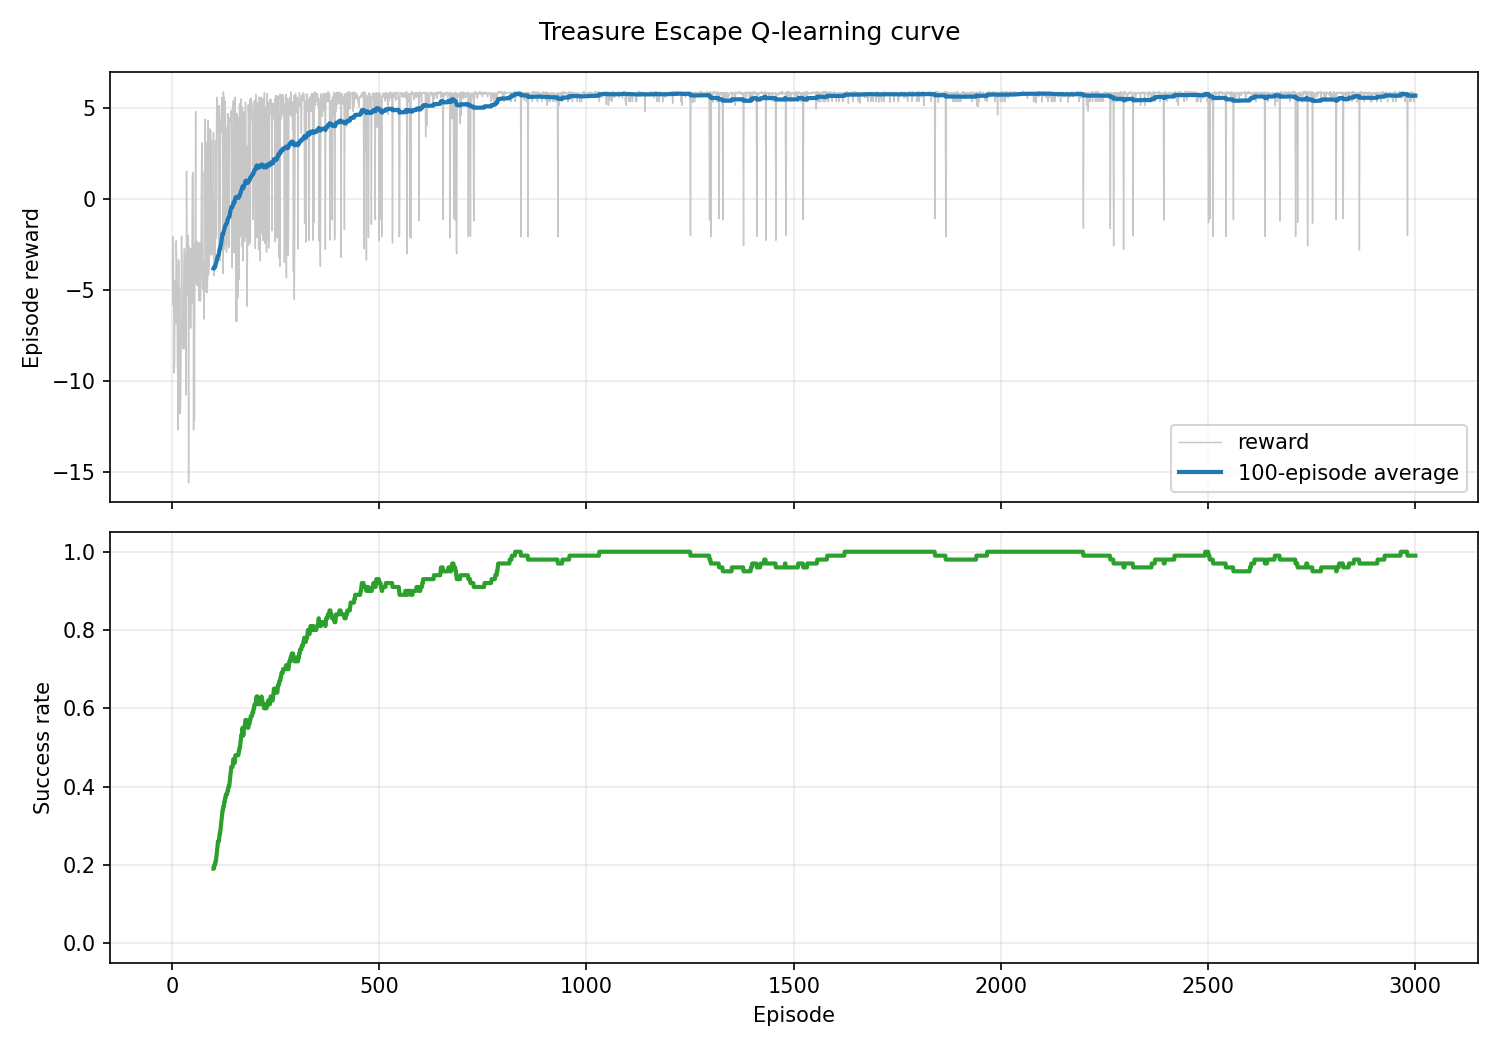


## 9. Wnioski

Agent Q-learning uczy się przejścia dwuetapowego: najpierw dochodzi do skarbu, a po jego zebraniu zmienia cel na wyjście. Trening odbywa się na wielu różnych mapach, więc agent startuje z różnych miejsc i uczy się polityki dla zróżnicowanego rozmieszczenia ścian, pułapek, skarbu oraz wyjścia. Krzywa uczenia zapisana w `learning_curve.png` pokazuje poprawę nagrody i skuteczności wraz z kolejnymi epizodami treningu.
